In [1]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q= 0.95)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

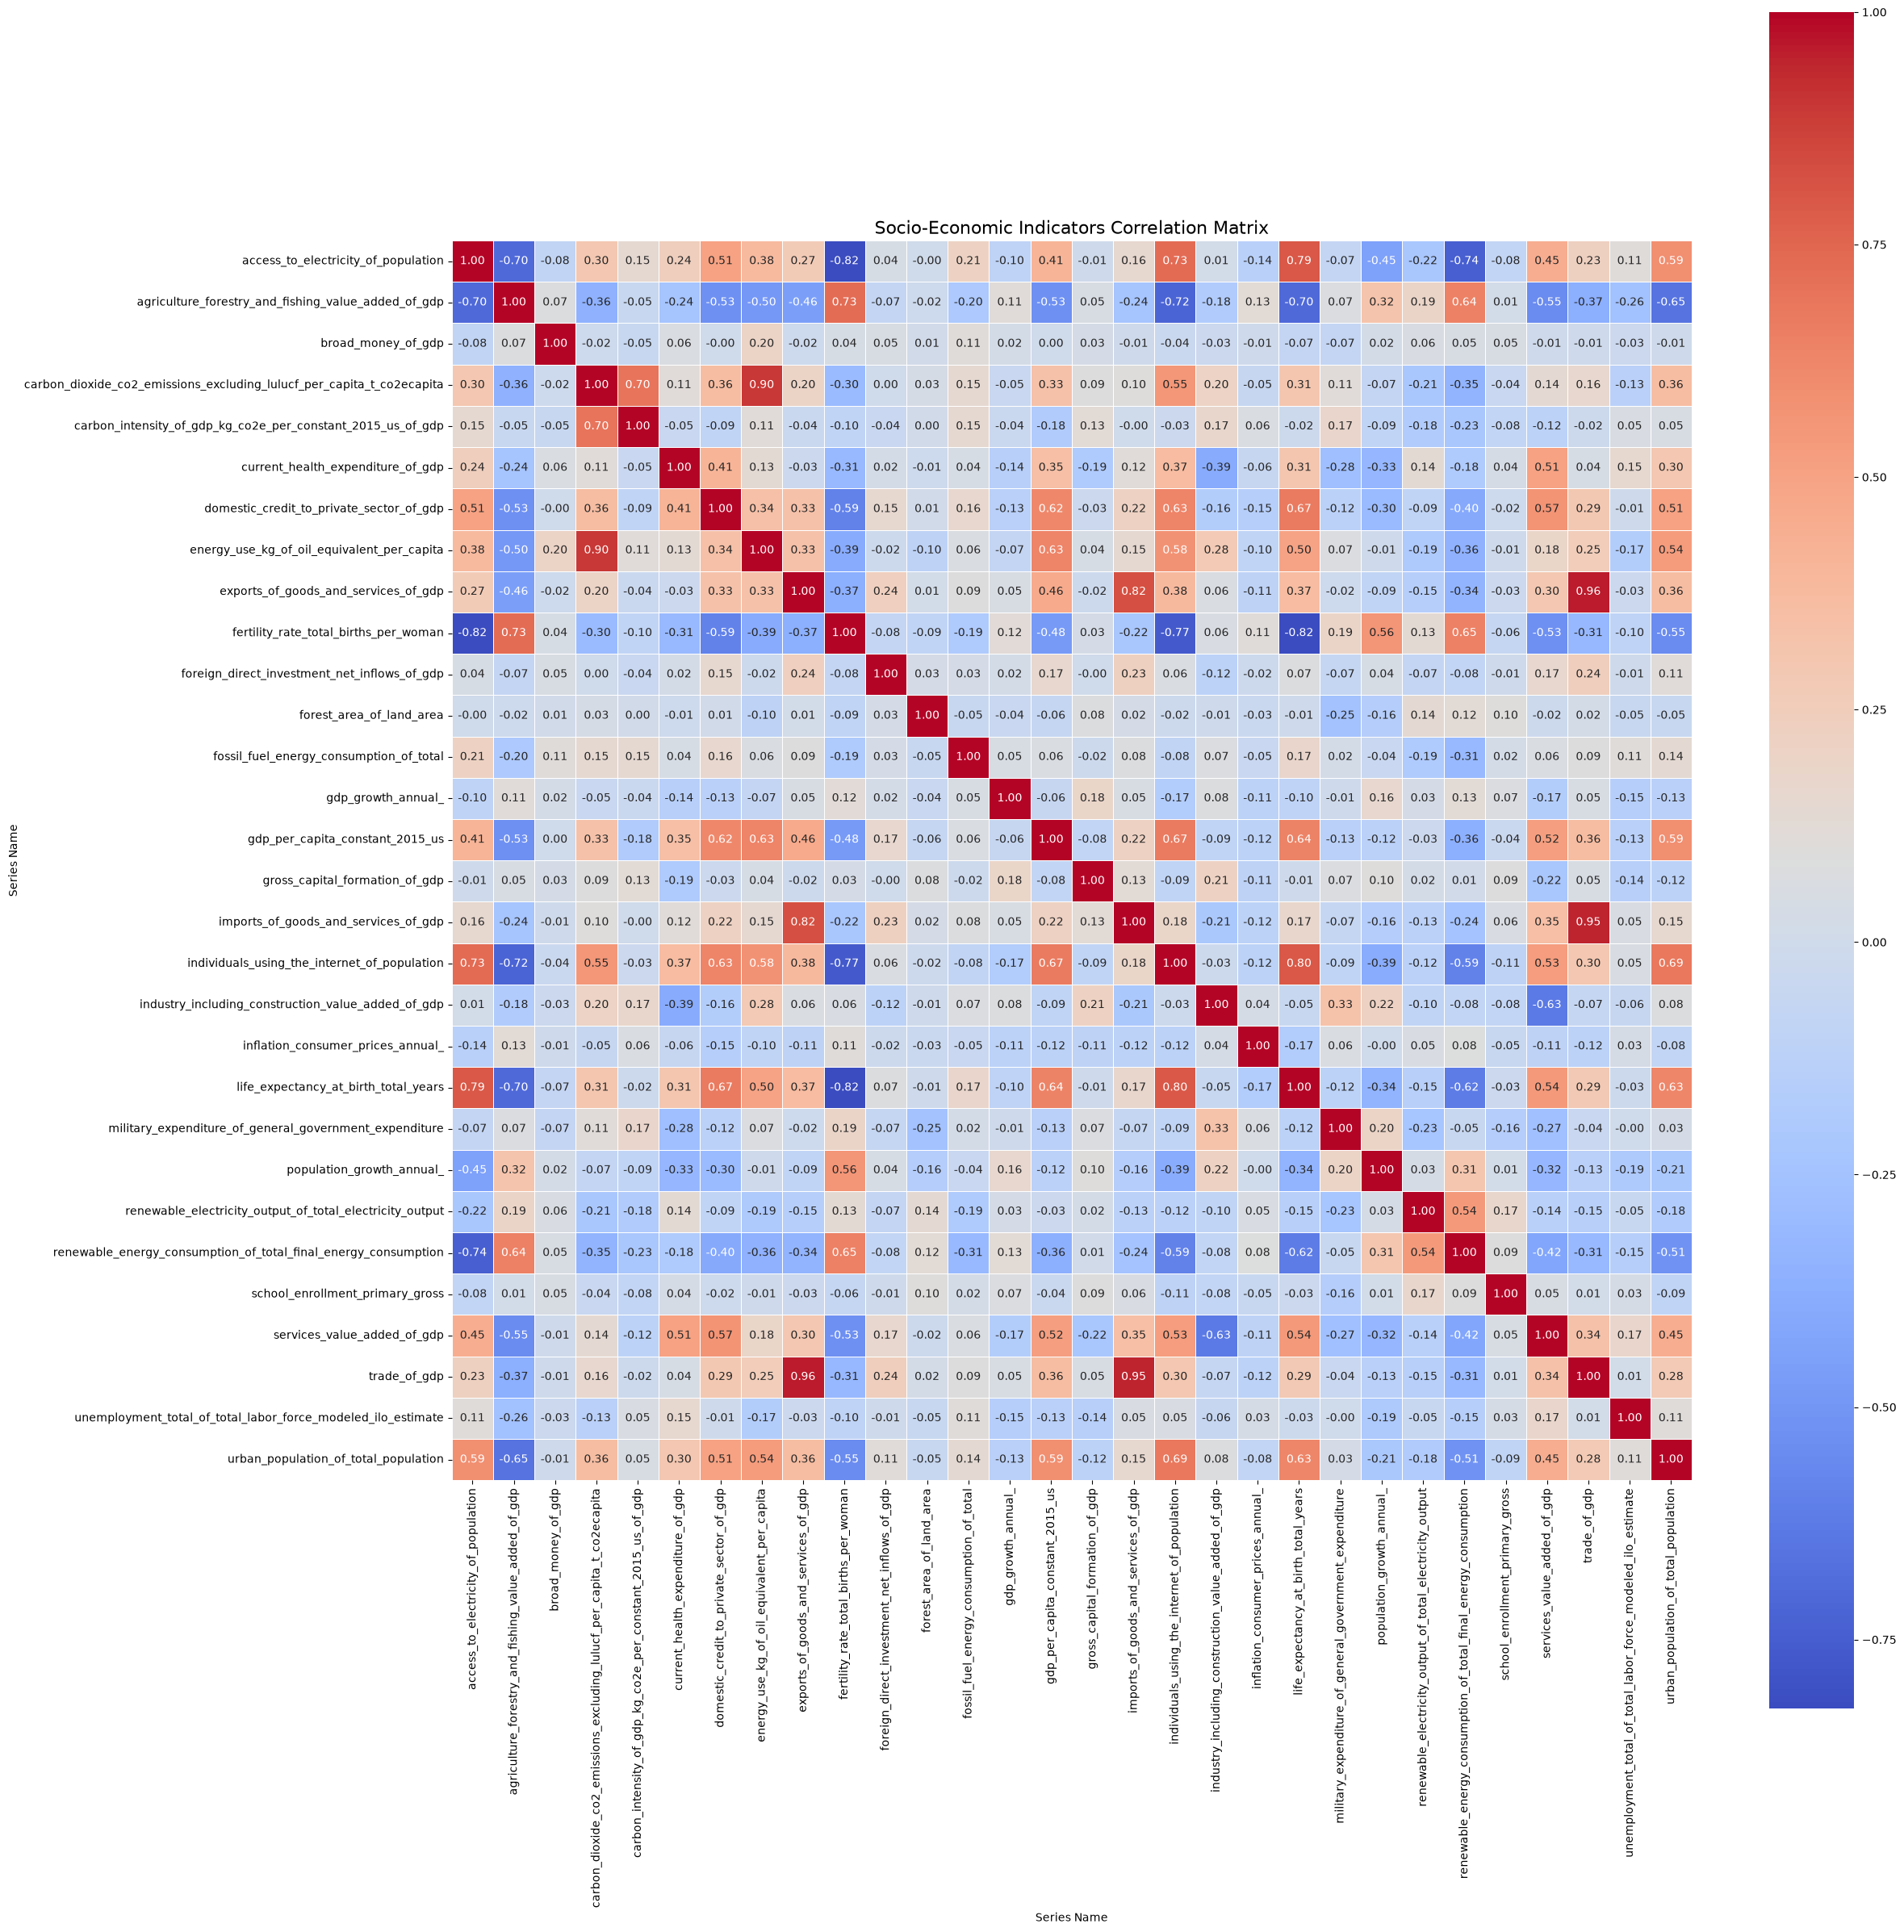

In [3]:
numeric_cols = df_countries.select_dtypes(include="number").columns.drop("year")

# 1. Compute the correlation matrix
corr_matrix = df_countries[numeric_cols].corr()

# 2. Plot the correlation matrix heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True,
    linewidths=0.5
)

plt.title("Socio-Economic Indicators Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()